# Exploratory Data Analysis (EDA)

This notebook analyzes the **Medical Transcriptions** dataset (`mtsamples.csv`) to understand the data quality, distribution of specialties, and text characteristics before building the extraction pipeline.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from spacy import displacy
import os

# Settings
pd.set_option('display.max_colwidth', 200)
sns.set_theme(style="whitegrid")

# Paths
DATA_PATH = "../data/mtsamples.csv"

## 1. Load Data

In [2]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}. Please download it from Kaggle.")

df = pd.read_csv(DATA_PATH)
print(f"Raw Data Shape: {df.shape}")

# Basic Cleaning
df = df.dropna(subset=['transcription'])
print(f"Clean Data Shape (after dropping null transcriptions): {df.shape}")

df.head(3)

Raw Data Shape: (4999, 6)
Clean Data Shape (after dropping null transcriptions): (4966, 6)


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with complaint of allergies.,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female presents with complaint of allergies. She used to have allergies when she lived in Seattle but she thinks they are worse here. In the past, she has tr...","allergy / immunology, allergic rhinitis, allergies, asthma, nasal sprays, rhinitis, nasal, erythematous, allegra, sprays, allergic,"
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climbing stairs, difficulty with airline seats, tying shoes, used to public seating, and lifting objects off the floor. He exercises three times a week at...","bariatrics, laparoscopic gastric bypass, weight loss programs, gastric bypass, atkin's diet, weight watcher's, body weight, laparoscopic gastric, weight loss, pounds, months, weight, laparoscopic,..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC today. He is a very pleasant gentleman who is 42 years old, 344 pounds. He is 5'9"". He has a BMI of 51. He has been overweight for ten years since...","bariatrics, laparoscopic gastric bypass, heart attacks, body weight, pulmonary embolism, potential complications, sleep study, weight loss, gastric bypass, anastomosis, loss, sleep, laparoscopic, ..."


## 2. Distribution of Specialties

C:\Users\jpoit\AppData\Local\Temp\ipykernel_26088\1940251472.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=specialty_counts.index, x=specialty_counts.values, palette="viridis")


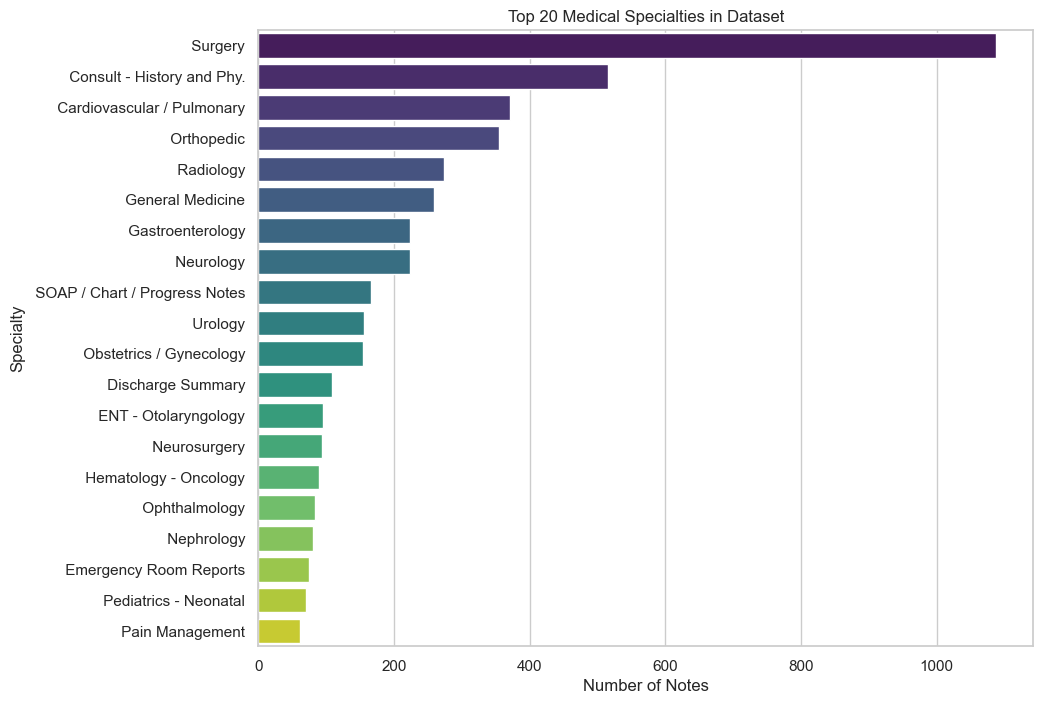

In [3]:
plt.figure(figsize=(10, 8))
specialty_counts = df['medical_specialty'].value_counts().head(20)
sns.barplot(y=specialty_counts.index, x=specialty_counts.values, palette="viridis")
plt.title("Top 20 Medical Specialties in Dataset")
plt.xlabel("Number of Notes")
plt.ylabel("Specialty")
plt.show()

## 3. Text Analysis (Word Counts)

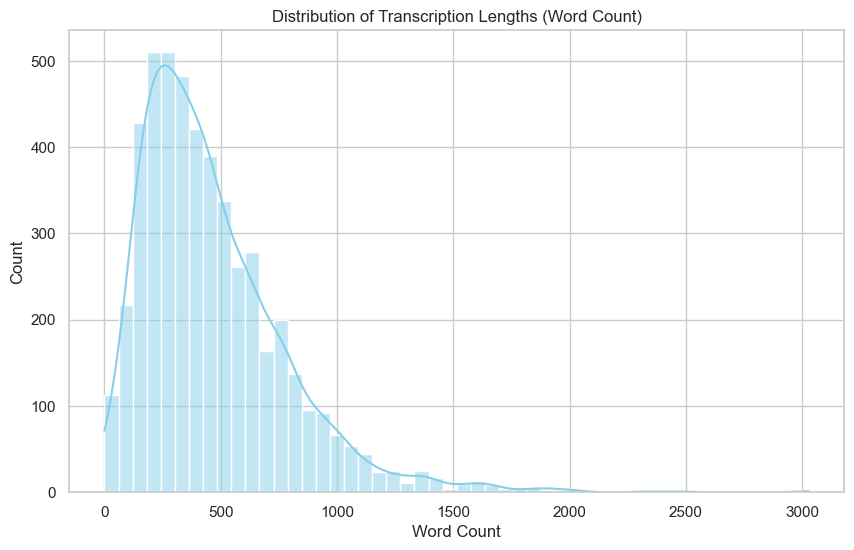

Average Word Count: 465.45
Min Word Count: 1
Max Word Count: 3029


In [4]:
df['word_count'] = df['transcription'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'], bins=50, kde=True, color="skyblue")
plt.title("Distribution of Transcription Lengths (Word Count)")
plt.xlabel("Word Count")
plt.show()

print(f"Average Word Count: {df['word_count'].mean():.2f}")
print(f"Min Word Count: {df['word_count'].min()}")
print(f"Max Word Count: {df['word_count'].max()}")

## 4. Entity Extraction Demo (SpaCy)
Demonstrating the `en_core_web_sm` model on a sample note. Note that a biomedical model (like `scispacy`) would perform better for specific medical terms, but this demonstrates the pipeline.

In [5]:
# Load SpaCy model
nlp = spacy.load("en_core_web_sm")

# Pick a random long note
sample_text = df[df['word_count'] > 200].sample(1)['transcription'].values[0]

print("Processing Note (First 500 chars)...")
print("-"*50)
print(sample_text[:500] + "...")
print("-"*50)

doc = nlp(sample_text)

# Visualize entities
displacy.render(doc, style="ent", jupyter=True)

Processing Note (First 500 chars)...
--------------------------------------------------
PREOPERATIVE DIAGNOSIS:,  Metopic synostosis with trigonocephaly.,POSTOPERATIVE DIAGNOSIS:,  Metopic synostosis with trigonocephaly.,PROCEDURES:  ,1.  Bilateral orbital frontal zygomatic craniotomy (skull base approach).,2.  Bilateral orbital advancement with (C-shaped osteotomies down to the inferior orbital rim) with bilateral orbital advancement with bone grafts.,3.  Bilateral forehead reconstruction with autologous graft.,4.  Advancement of the temporalis muscle bilaterally.,5.  Barrel-stave...
--------------------------------------------------


## 6. Medical Coding Analysis (ICD-10 & CPT)

We will now analyze the output of our **Medical Coding Pipeline**. The system has mapped extracted entities to standard codes.

**Note:** This analysis requires `data/output/production_results.csv` to exist (run `main.py` first).

In [ ]:
import ast

RESULTS_PATH = "../data/output/production_results.csv"

if os.path.exists(RESULTS_PATH):
    results_df = pd.read_csv(RESULTS_PATH)
    print(f"Loaded Production Results: {results_df.shape}")
    
    # Helper to parse the stringified JSON lists
    def extract_codes(str_list, system_filter=None):
        try:
            data = ast.literal_eval(str_list)
            if not isinstance(data, list):
                return []
            # Extract ONLY mapped codes (ignore UNMAPPED)
            codes = []
            for item in data:
                if item.get('code') != 'UNMAPPED':
                    if system_filter and item.get('system') != system_filter:
                        continue
                    # Format: Code (Description)
                    label = f"{item['code']} - {item.get('description', 'Unknown')}"
                    codes.append(label)
            return codes
        except:
            return []

    # 1. ICD-10 Problems
    all_icd10 = []
    for row in results_df['coded_problems']:
        all_icd10.extend(extract_codes(row, "ICD-10-CM"))
        
    # 2. CPT Treatments/Tests
    all_cpt = []
    for row in results_df['coded_treatments']:
        all_cpt.extend(extract_codes(row, "CPT/HCPCS"))
    for row in results_df['coded_tests']:
        all_cpt.extend(extract_codes(row, "CPT/HCPCS"))

    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # ICD-10 Chart
    if all_icd10:
        pd.Series(all_icd10).value_counts().head(10).sort_values().plot(kind='barh', ax=ax1, color='salmon')
        ax1.set_title("Top 10 ICD-10-CM Codes Identified")
        ax1.set_xlabel("Count")
    else:
        ax1.text(0.5, 0.5, 'No ICD-10 Data Found', ha='center')

    # CPT Chart
    if all_cpt:
        pd.Series(all_cpt).value_counts().head(10).sort_values().plot(kind='barh', ax=ax2, color='skyblue')
        ax2.set_title("Top 10 CPT/HCPCS Codes Identified")
        ax2.set_xlabel("Count")
    else:
        ax2.text(0.5, 0.5, 'No CPT Data Found', ha='center')

    plt.tight_layout()
    plt.show()
    
else:
    print("Production results file not found. Please run main.py first.")